# 07 — Inference + KV-Cache
Compares naive vs cached generation. Shows the speedup.

Naive (O(T²)): 114.3 tok/s  (437 ms)


KV-cache (O(T)): 239.1 tok/s  (209 ms)


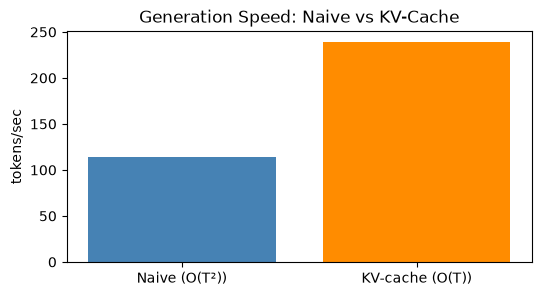


Speedup: 2.1×


In [1]:
import time, torch, matplotlib.pyplot as plt
from model.config import TINY_CONFIG
from model.gpt import GPT
from inference.generate import generate_naive, generate_cached
import tiktoken

enc   = tiktoken.get_encoding("gpt2")
ckpt  = torch.load("../checkpoints/tiny_pretrain.pt", map_location="cpu", weights_only=False)
model = GPT(TINY_CONFIG)
model.load_state_dict(ckpt["model"])
model.eval()

prompt_text = "To be or not to be"
prompt_ids  = torch.tensor(enc.encode(prompt_text))
MAX_NEW = 50

# Warm up
generate_cached(model, prompt_ids, max_new=5, temperature=0.0)

# Benchmark
results = {}
for name, fn in [("Naive (O(T²))", generate_naive), ("KV-cache (O(T))", generate_cached)]:
    times = []
    for _ in range(5):
        t0 = time.perf_counter()
        out = fn(model, prompt_ids, max_new=MAX_NEW, temperature=0.8, top_k=40)
        times.append(time.perf_counter() - t0)
    avg_ms = sum(times)/len(times) * 1000
    tps    = MAX_NEW / (avg_ms / 1000)
    results[name] = tps
    print(f"{name}: {tps:.1f} tok/s  ({avg_ms:.0f} ms)")

plt.figure(figsize=(6, 3))
plt.bar(results.keys(), results.values(), color=["steelblue", "darkorange"])
plt.ylabel("tokens/sec"); plt.title("Generation Speed: Naive vs KV-Cache")
plt.savefig("../benchmarks/plots/kvcache_speedup.png", dpi=120, bbox_inches="tight"); plt.show()
speedup = results["KV-cache (O(T))"] / results["Naive (O(T²))"]
print(f"\nSpeedup: {speedup:.1f}×")